In [1]:
import os
import glob
import pandas as pd
import numpy as np
import datetime as datetime
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import math

In [3]:
from scipy.signal import butter, filtfilt

In [4]:
import kneed
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler

# Open Sound Files

In [5]:
def load_config(directory):
    file_name=[f for f in glob.glob(directory + "/*.RNH")]
    f = open(file_name[0],'r')
    conf = f.read()    
    t = {}
    conf = conf.split("\n")
    for i in conf:
        if i != "":
            temp = i.split(",")
            t[temp[0]] = temp[1].strip()
    return t

In [6]:
dir = {1:"../sound_proj_2/data/Raw-data/1-Romruedee-Romklao-12-20-Mar-2014/AU1_0001/",
        2:"../sound_proj_2/data/Raw-data/2-Central-Village-3-11-Apr-2014/AU1_0002/",
        3:"../sound_proj_2/data/Raw-data/3-Bangchalong-Canal-3-11-Apr-2014/AU1_0001/",
        4:"../sound_proj_2/data/Raw-data/4-ThanaPlace-28-Apr-7-May-2014/AU1_0002/",
        5:"../sound_proj_2/data/Raw-data/5-Romklao27-28-Apr-7-May-2014/AU1_0001/",
        6:"../sound_proj_2/data/Raw-data/6-BangPla43-10-17-May-2014/AU1_0001/",
        7:"../sound_proj_2/data/Raw-data/7-Bangsaothong-10-17-May-2014/AU1_0002/",
        8:"../sound_proj_2/data/Raw-data/8-Habitia-Ramindra-20-26-May-2014/AU1_0001/"}

file_dir = dir[1]
conf = load_config(dir[1])
conf

{'File name': 'AU1_0001',
 'File number': '114',
 'Data number': '6795889',
 'Frequency-weight': 'A',
 'Time-weight': 'Slow',
 'Filter': '-',
 'Center/High pass filter cutoff': '-',
 'Low pass filter cutoff': '-',
 'Time setting': 'Manual',
 'Measurment time': '188:46:28',
 'Sampling': '100msec',
 'Start Time': '2014/03/12 18:45:42',
 'Stop Time': '2014/03/20 15:32:11'}

In [7]:
file_names = [f for f in glob.glob(file_dir + "/*.RND")]

In [8]:
open_files = [open(f,'r').read().replace(' ',"").replace(",","").split('\n') for f in file_names]

data_concat = [x for lst in open_files for x in lst]
data_cleaned = ' '.join(data_concat).split()
sound_lists = [float(data.replace('O','0')) for data in data_cleaned]


In [9]:
print(len(sound_lists))

6795889


In [10]:
def parse_date(date):
    return datetime.datetime.strptime(date,'%Y/%m/%d %H:%M:%S')

In [11]:
start = parse_date(conf['Start Time'])
time = [start + datetime.timedelta(milliseconds=(100*i)) for i in range(len(sound_lists))]
df = pd.DataFrame({'Period start':time, 'Leq':sound_lists})

In [12]:
min(time), max(time)

(datetime.datetime(2014, 3, 12, 18, 45, 42),
 datetime.datetime(2014, 3, 20, 15, 32, 10, 800000))

In [13]:
df

,Period start,Leq
0,2014-03-12 18:45:42.000,51.6
1,2014-03-12 18:45:42.100,51.6
2,2014-03-12 18:45:42.200,51.6
3,2014-03-12 18:45:42.300,51.6
4,2014-03-12 18:45:42.400,51.6
...,...,...
6795884,2014-03-20 15:32:10.400,51.9
6795885,2014-03-20 15:32:10.500,51.9
6795886,2014-03-20 15:32:10.600,51.9
6795887,2014-03-20 15:32:10.700,51.9


In [14]:
one_hr = 36000

half_day = one_hr * 12
day = one_hr * 24
week = 7 * day

In [15]:
df = df[:day+1]
n_data_points = len(df)
print(n_data_points)

864001


1 hr = 36000
1 hr = 60 min

# Event Detection

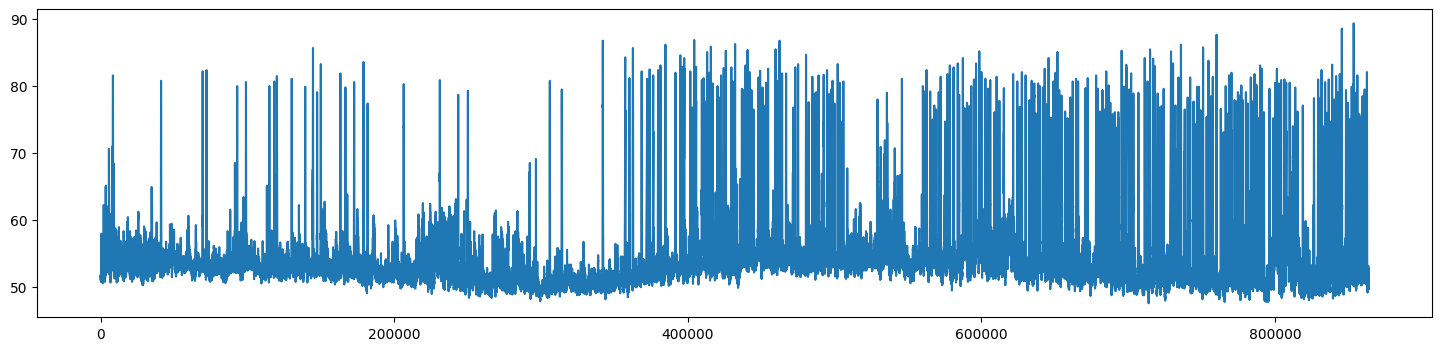

In [16]:
plt.figure(figsize=(18,4))
plt.plot(df['Leq'])
plt.show()

## Preprocessing

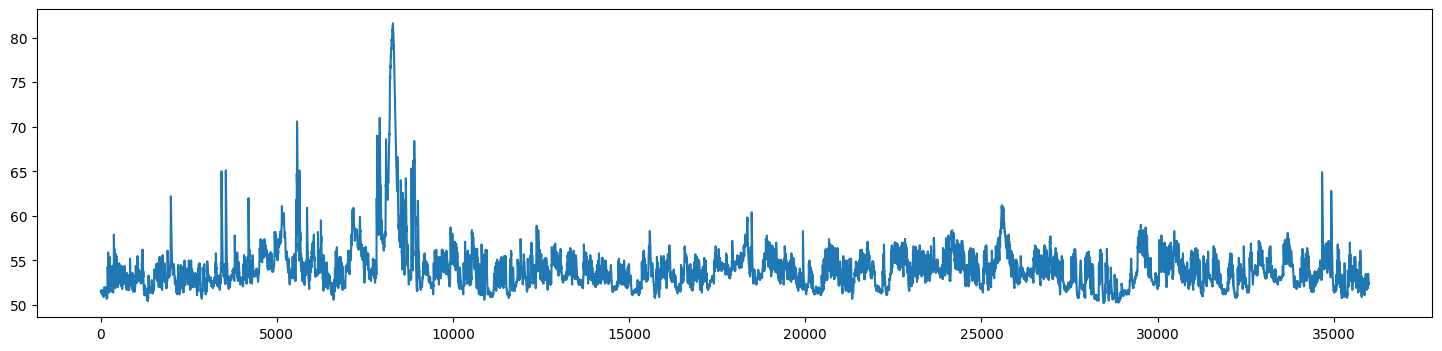

In [17]:
plt.figure(figsize=(18,4))
plt.plot(df['Leq'][:one_hr+1])
plt.show()

### Time Convert

### Filter using Cut-off

In [18]:
def cutoff(r, data):
    r = (100 - r) / 1000
    b, a = butter(4, r)
    filtered = filtfilt(b, a, data)
    return filtered

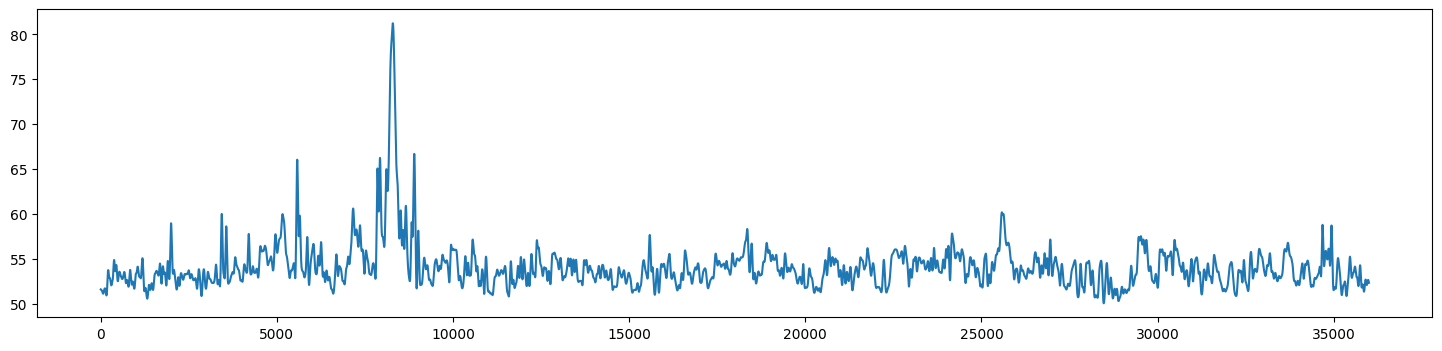

In [19]:
rate = 70
if(rate < 100):
    sound_cutoff = cutoff(rate, df['Leq'])
    plt.figure(figsize=(18,4))
    plt.plot(sound_cutoff[:one_hr+1])
    plt.show()
else:
    print("Error")

In [20]:
df = df.assign(Leq_filtered=sound_cutoff)

In [21]:
df

,Period start,Leq,Leq_filtered
0,2014-03-12 18:45:42.000,51.6,51.607917
1,2014-03-12 18:45:42.100,51.6,51.604079
2,2014-03-12 18:45:42.200,51.6,51.600349
3,2014-03-12 18:45:42.300,51.6,51.596730
4,2014-03-12 18:45:42.400,51.6,51.593228
...,...,...,...
863996,2014-03-13 18:45:41.600,52.5,51.402315
863997,2014-03-13 18:45:41.700,52.4,51.413325
863998,2014-03-13 18:45:41.800,52.3,51.422784
863999,2014-03-13 18:45:41.900,52.3,51.430795


### Standardization

In [22]:
df_copy = df.copy()

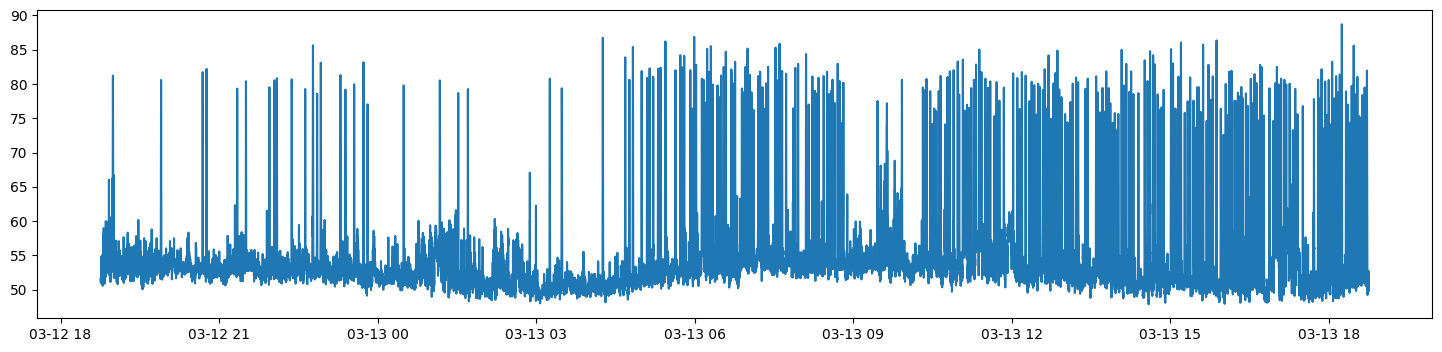

In [23]:
plt.figure(figsize=(18,4))
plt.plot(df_copy['Period start'], df_copy['Leq_filtered'])
plt.show()

In [24]:
test2 = np.array(df_copy['Leq_filtered'])
test2 = test2.reshape(-1,1)

In [25]:
scaler = StandardScaler()
test2_normalized = scaler.fit_transform(test2)

In [26]:
df_copy['sound intensity normailzed'] = test2_normalized

In [27]:
df_copy

,Period start,Leq,Leq_filtered,sound intensity normailzed
0,2014-03-12 18:45:42.000,51.6,51.607917,-0.493576
1,2014-03-12 18:45:42.100,51.6,51.604079,-0.494258
2,2014-03-12 18:45:42.200,51.6,51.600349,-0.494921
3,2014-03-12 18:45:42.300,51.6,51.596730,-0.495564
4,2014-03-12 18:45:42.400,51.6,51.593228,-0.496186
...,...,...,...,...
863996,2014-03-13 18:45:41.600,52.5,51.402315,-0.530107
863997,2014-03-13 18:45:41.700,52.4,51.413325,-0.528151
863998,2014-03-13 18:45:41.800,52.3,51.422784,-0.526470
863999,2014-03-13 18:45:41.900,52.3,51.430795,-0.525047


## Clustering

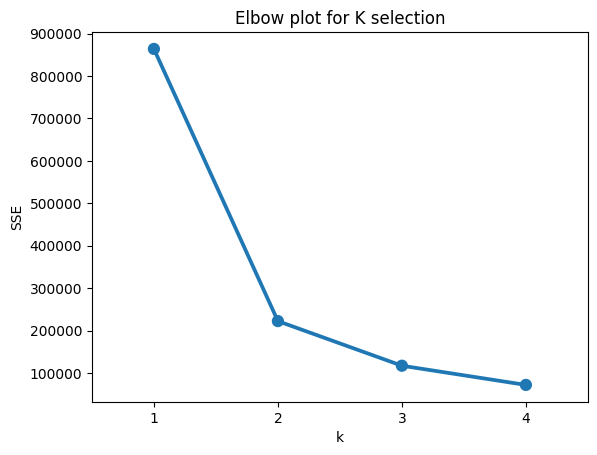

In [28]:
sse = {}

for k in range(1, 5):
  kmeans = KMeans(n_clusters=k, random_state=0).fit(test2_normalized)
  sse[k] = kmeans.inertia_

plt.title('Elbow plot for K selection')
plt.xlabel('k')
plt.ylabel('SSE')
sns.pointplot(x=list(sse.keys()), y=list(sse.values()))
plt.show()

In [29]:
kn = kneed.KneeLocator(
    x=list(sse.keys()), 
    y=list(sse.values()), 
    curve='convex', 
    direction='decreasing', S=0.0)

In [30]:
k = kn.knee
kmeans_best = KMeans(n_clusters=k, random_state=0).fit(test2_normalized)

In [31]:
df_copy['cluster'] = kmeans_best.labels_

In [32]:
df_copy

,Period start,Leq,Leq_filtered,sound intensity normailzed,cluster
0,2014-03-12 18:45:42.000,51.6,51.607917,-0.493576,0
1,2014-03-12 18:45:42.100,51.6,51.604079,-0.494258,0
2,2014-03-12 18:45:42.200,51.6,51.600349,-0.494921,0
3,2014-03-12 18:45:42.300,51.6,51.596730,-0.495564,0
4,2014-03-12 18:45:42.400,51.6,51.593228,-0.496186,0
...,...,...,...,...,...
863996,2014-03-13 18:45:41.600,52.5,51.402315,-0.530107,0
863997,2014-03-13 18:45:41.700,52.4,51.413325,-0.528151,0
863998,2014-03-13 18:45:41.800,52.3,51.422784,-0.526470,0
863999,2014-03-13 18:45:41.900,52.3,51.430795,-0.525047,0


In [33]:
clusters = np.unique(kmeans_best.labels_)

In [34]:
avg_cluster = [df_copy[df_copy['cluster'] == i]['Leq_filtered'].mean() for i in range(kn.knee)]
avg_cluster

[53.057773773473244, 72.10036979955379]

In [35]:
max_cluster = np.array(avg_cluster).argmax()
max_cluster

1

## Peak Extraction

In [36]:
peak_count = len(df_copy[df_copy['cluster'] == max_cluster])
unix_time = np.array(df_copy['Period start'])
time_on_max_clusters = np.array(df_copy[df_copy['cluster'] == max_cluster].index)
print("Peak count: %d" % peak_count)

Peak count: 60258


In [37]:
X = time_on_max_clusters.reshape(-1,1)

### DBSCAN

In [38]:
df_dbscan = df.copy()

In [39]:
dbscan = DBSCAN(eps=150, min_samples=10).fit(X)

In [40]:
df_dbscan = df_dbscan.iloc[time_on_max_clusters]
df_dbscan['peak group'] = dbscan.labels_

In [41]:
df_dbscan = df_dbscan[df_dbscan['peak group'] != -1]
df_dbscan

,Period start,Leq,Leq_filtered,peak group
5560,2014-03-12 18:54:58.000,57.9,62.883520,0
5561,2014-03-12 18:54:58.100,57.8,63.210629,0
5562,2014-03-12 18:54:58.200,61.8,63.525624,0
5563,2014-03-12 18:54:58.300,63.9,63.827184,0
5564,2014-03-12 18:54:58.400,64.4,64.114029,0
...,...,...,...,...
862732,2014-03-13 18:43:35.200,63.0,63.311247,292
862733,2014-03-13 18:43:35.300,62.8,63.148041,292
862734,2014-03-13 18:43:35.400,62.6,62.987176,292
862735,2014-03-13 18:43:35.500,62.5,62.828494,292


In [42]:
n = len(np.unique(dbscan.labels_))
dbscan_labels = df_dbscan['peak group'].unique()

In [43]:
df2 = df_dbscan['peak group']

In [44]:
df_merge = pd.concat([df, df2], axis=1)
df_merge['peak group'] = df_merge['peak group'].fillna(-1)
df_merge

,Period start,Leq,Leq_filtered,peak group
0,2014-03-12 18:45:42.000,51.6,51.607917,-1.0
1,2014-03-12 18:45:42.100,51.6,51.604079,-1.0
2,2014-03-12 18:45:42.200,51.6,51.600349,-1.0
3,2014-03-12 18:45:42.300,51.6,51.596730,-1.0
4,2014-03-12 18:45:42.400,51.6,51.593228,-1.0
...,...,...,...,...
863996,2014-03-13 18:45:41.600,52.5,51.402315,-1.0
863997,2014-03-13 18:45:41.700,52.4,51.413325,-1.0
863998,2014-03-13 18:45:41.800,52.3,51.422784,-1.0
863999,2014-03-13 18:45:41.900,52.3,51.430795,-1.0


In [45]:
# plt.figure(figsize=(16,4))
# plt.plot(df_merge['time'], df_merge['sound intensity filtered'])

# for c in dbscan_labels:
#     cond = df_merge[df_merge['peak group'] == c]
#     plt.plot(cond['time'], cond['sound intensity filtered'], "o")
# plt.show()

In [46]:
print("Clustered peak count: %d" % len(set(dbscan_labels)))

Clustered peak count: 293


### Equivalent Continuous Sound Presure Level

In [47]:
def computeL_eq_t(data):
    sum_pow = np.sum(np.power(10, data/10))
    x = 1/len(data) * sum_pow 
    return 10 * math.log(x,10)

def SoundAddition(data):
    x = np.sum(np.power(10, data/10))
    return 10 * math.log(x,10)

def computeSEL(data):
    return computeL_eq_t(data) + 10 * math.log((len(data)*100)/1000)

In [48]:
results = []
hours = [[] for i in range(int(math.ceil(n_data_points//36000)))]

In [49]:
data_dict = [{c:np.nan} for c in dbscan_labels]
peak_median = [np.median(df_dbscan[df_dbscan['peak group'] == i].index) for i in range(n) if (len(df_dbscan[df_dbscan['peak group'] == i]) != 0)]

In [50]:
for c in dbscan_labels:
    c_data = df_merge[df_merge['peak group'] == c].index
    min_t, max_t = c_data.min(), c_data.max()
    peak_t = int(peak_median[c])

    in_which_hour = min_t//36000

    raw = np.array(df_merge[df_merge['peak group'] == c]['Leq'])
    Leq = computeL_eq_t(raw)
    LAE = computeSEL(raw)

    r = {"hours":in_which_hour+1, "start_time": unix_time[min_t], "end_time": unix_time[max_t], "peak_time": peak_t,
         "interval": unix_time[max_t]-unix_time[min_t], 'median':peak_median[c], 'Leq':Leq, 'Lae':LAE}

    # print ("Cluster#%d: L_eq, %d=%f dB(A), L_AE=%f dB(A)" % (c, len(raw), Leq, LAE))
    
    results.append(r)

df_result = pd.DataFrame(results)

In [51]:
df_result['interval'] = df_result['interval'] / np.timedelta64(1, 's')

In [52]:
df_result.head()

,hours,start_time,end_time,peak_time,interval,median,Leq,Lae
0,1,2014-03-12 18:54:58.000,2014-03-12 18:55:01.500,5577,3.5,5577.5,66.250234,79.059572
1,1,2014-03-12 18:58:46.100,2014-03-12 18:59:45.400,8225,59.3,8225.5,74.801470,112.130434
2,1,2014-03-12 19:00:29.700,2014-03-12 19:00:34.100,8899,4.4,8899.0,65.628950,80.669724
3,2,2014-03-12 19:53:58.700,2014-03-12 19:54:23.100,41089,24.4,41089.0,75.265833,107.252565
4,2,2014-03-12 20:41:14.200,2014-03-12 20:41:35.200,69427,21.0,69427.0,76.936949,107.429680


In [53]:
max(df_result['interval']), min(df_result['interval'])

(59.3, 1.6)

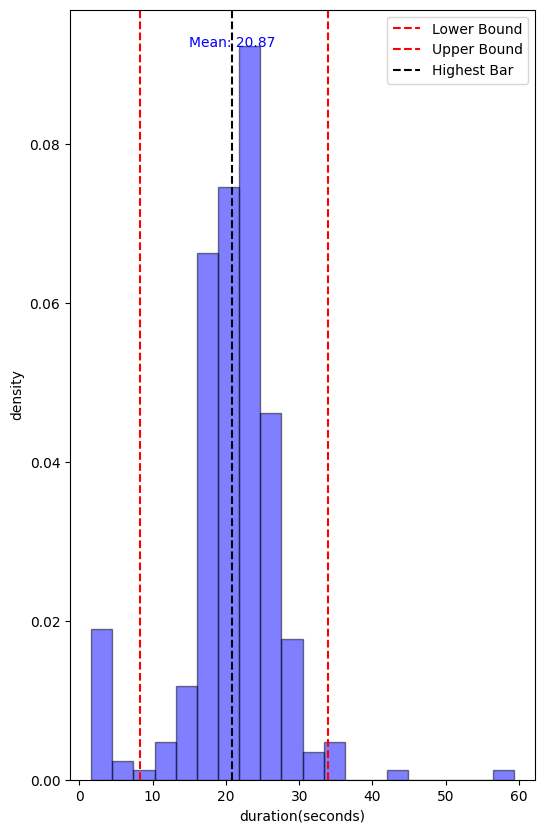

In [54]:
data = df_result[df_result['interval'] < 200]['interval']
# data = df_result['interval']

plt.figure(figsize=(6,10))
# Calculate IQR
Q1 = np.percentile(data, 25)
Q3 = np.percentile(data, 75)
IQR = Q3 - Q1

# Calculate upper and lower bounds
lower_bound = Q1 - 1.5 * IQR
if lower_bound < 0:
    lower_bound = 0

upper_bound = Q3 + 1.5 * IQR

# Create the histogram with density probability and blue color
bin_counts, bin_edges, _ = plt.hist(data, bins=20, density=True, color='blue', alpha=0.5, edgecolor='black')

# Add IQR boundaries
plt.axvline(lower_bound, color='red', linestyle='--', label='Lower Bound')
plt.axvline(upper_bound, color='red', linestyle='--', label='Upper Bound')

# Find the bin with the highest count
highest_bin_index = np.argmax(bin_counts)
highest_bin_value = bin_edges[highest_bin_index]

# Calculate the mean
mean_value = np.mean(data)

# Add a line at the highest bar
plt.axvline(mean_value, color='black', linestyle='--', label='Highest Bar')

# Display the mean value at the highest bar
plt.text(mean_value, max(bin_counts), f'Mean: {mean_value:.2f}', color='blue', ha='center')

# Set x-axis tick values and labels
# plt.xticks([0, 50, 100, 150, 200])

# Show the legend
plt.legend()

# giving X and Y labels
plt.xlabel("duration(seconds)")
plt.ylabel("density")

# Display the plot
plt.show()

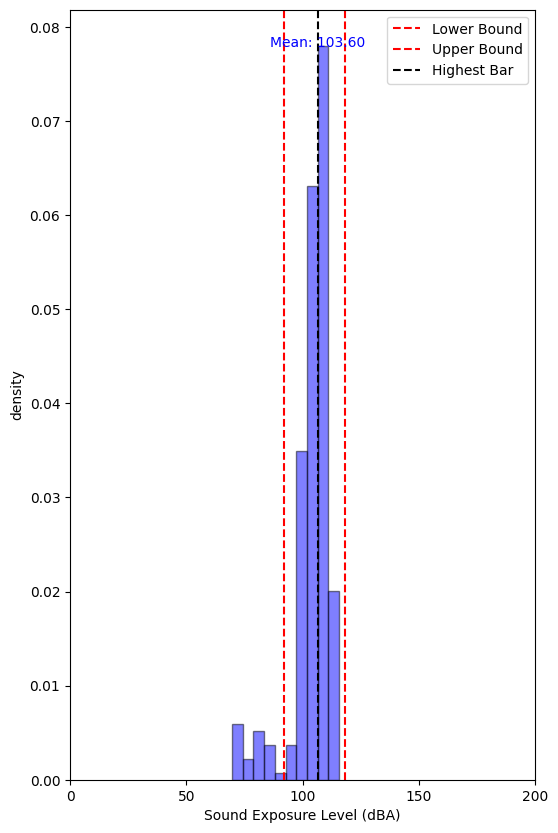

In [55]:
sound_info = df_result['Lae']

plt.figure(figsize=(6,10))
# Calculate IQR
Q1 = np.percentile(sound_info, 25)
Q3 = np.percentile(sound_info, 75)
IQR = Q3 - Q1

# Calculate upper and lower bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Create the histogram with density probability and blue color
bin_counts, bin_edges, _ = plt.hist(sound_info, bins=10, density=True, color='blue', alpha=0.5, edgecolor='black')

# Add IQR boundaries
plt.axvline(lower_bound, color='red', linestyle='--', label='Lower Bound')
plt.axvline(upper_bound, color='red', linestyle='--', label='Upper Bound')

highest_bin_index = np.argmax(bin_counts)
highest_bin_value = bin_edges[highest_bin_index]
mean_value = np.mean(sound_info)

plt.axvline(highest_bin_value, color='black', linestyle='--', label='Highest Bar')
plt.text(highest_bin_value, max(bin_counts), f'Mean: {mean_value:.2f}', color='blue', ha='center')
plt.xticks([0, 50, 100, 150, 200])

plt.legend()
plt.xlabel("Sound Exposure Level (dBA)")
plt.ylabel("density")
plt.show()

In [56]:
aircraft_info = []

{'whiskers': [<matplotlib.lines.Line2D at 0x2472e735360>,
 'caps': [<matplotlib.lines.Line2D at 0x2472e737f40>,
 'boxes': [<matplotlib.lines.Line2D at 0x2472e7347c0>],
 'medians': [<matplotlib.lines.Line2D at 0x2472e734d00>],
 'fliers': [<matplotlib.lines.Line2D at 0x2472e7368c0>],
 'means': []}

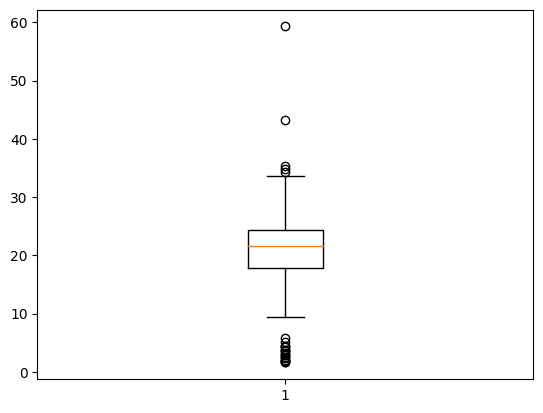

In [57]:
plt.boxplot(df_result['interval'])

In [58]:
Q1 = np.percentile(df_result['interval'], 25)
Q3 = np.percentile(df_result['interval'], 75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_result_cleaned = df_result[~((df_result['interval'] < lower_bound) | (df_result['interval'] > upper_bound))]
df_result_cleaned.head()

,hours,start_time,end_time,peak_time,interval,median,Leq,Lae
3,2,2014-03-12 19:53:58.700,2014-03-12 19:54:23.100,41089,24.4,41089.0,75.265833,107.252565
4,2,2014-03-12 20:41:14.200,2014-03-12 20:41:35.200,69427,21.0,69427.0,76.936949,107.429680
5,2,2014-03-12 20:45:33.400,2014-03-12 20:45:59.800,72046,26.4,72046.0,77.152073,109.923521
6,3,2014-03-12 21:20:27.900,2014-03-12 21:20:47.600,92957,19.7,92957.5,75.076520,104.933339
7,3,2014-03-12 21:30:25.900,2014-03-12 21:30:44.700,98933,18.8,98933.0,75.446220,104.837839


{'whiskers': [<matplotlib.lines.Line2D at 0x2472d5e1f30>,
 'caps': [<matplotlib.lines.Line2D at 0x2472d5e0fd0>,
 'boxes': [<matplotlib.lines.Line2D at 0x2472d5e2230>],
 'medians': [<matplotlib.lines.Line2D at 0x2472d5e33d0>],
 'fliers': [<matplotlib.lines.Line2D at 0x2472d5e0790>],
 'means': []}

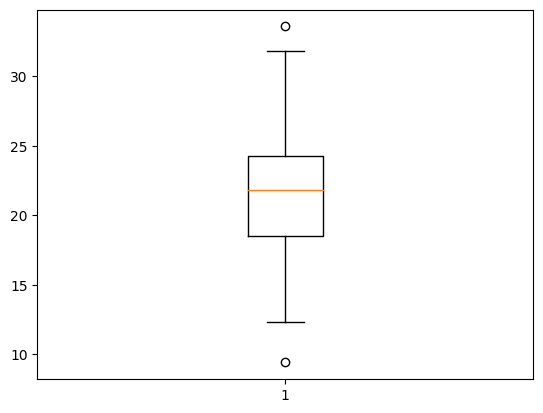

In [59]:
plt.boxplot(df_result_cleaned['interval'])

In [60]:
df_result_cleaned

,hours,start_time,end_time,peak_time,interval,median,Leq,Lae
3,2,2014-03-12 19:53:58.700,2014-03-12 19:54:23.100,41089,24.4,41089.0,75.265833,107.252565
4,2,2014-03-12 20:41:14.200,2014-03-12 20:41:35.200,69427,21.0,69427.0,76.936949,107.429680
5,2,2014-03-12 20:45:33.400,2014-03-12 20:45:59.800,72046,26.4,72046.0,77.152073,109.923521
6,3,2014-03-12 21:20:27.900,2014-03-12 21:20:47.600,92957,19.7,92957.5,75.076520,104.933339
7,3,2014-03-12 21:30:25.900,2014-03-12 21:30:44.700,98933,18.8,98933.0,75.446220,104.837839
...,...,...,...,...,...,...,...,...
288,24,2014-03-13 18:34:32.500,2014-03-13 18:34:49.500,857390,17.0,857390.0,71.492393,99.883178
289,24,2014-03-13 18:36:30.200,2014-03-13 18:36:47.600,858569,17.4,858569.0,71.565550,100.187559
290,24,2014-03-13 18:38:18.400,2014-03-13 18:38:35.700,859650,17.3,859650.5,73.824076,102.388778
291,24,2014-03-13 18:40:37.400,2014-03-13 18:40:58.600,861060,21.2,861060.0,75.079526,105.666597


In [63]:
df_result_cleaned.to_csv("../sound_proj_2/data/Processed-data/output.csv", index=False)

In [61]:
for i in range(n_data_points//36000):
    data = df_result_cleaned[df_result_cleaned['hours'] == i+1]
    Lae_in_this_hour = np.array(data['Lae'])
    Leq_in_this_hour = np.array(data['Leq'])

    print(f"Hour#{i+1}")

    if(len(Lae_in_this_hour) == 0 and len(Leq_in_this_hour) == 0):
        print("no aircraft.")
    else:
        Leq = SoundAddition(Leq_in_this_hour)
        Lae = SoundAddition(Lae_in_this_hour)
        
        print ("Hour#%d has %d aircraft(s) and sum of Leq of those aircraft(s) is %f and Lae is %f." % ((i+1), len(data), Leq, Lae))

    # aircraft_info.append({'start_time':time_start, 'end_time':time_end, 'aircrafts':len([df_result_cleaned['hours'] == i])})

    print()

Hour#1
no aircraft.

Hour#2
Hour#2 has 3 aircraft(s) and sum of Leq of those aircraft(s) is 81.300764 and Lae is 113.153513.

Hour#3
Hour#3 has 2 aircraft(s) and sum of Leq of those aircraft(s) is 78.275602 and Lae is 107.896152.

Hour#4
Hour#4 has 5 aircraft(s) and sum of Leq of those aircraft(s) is 82.204668 and Lae is 113.970926.

Hour#5
Hour#5 has 6 aircraft(s) and sum of Leq of those aircraft(s) is 84.011459 and Lae is 115.371526.

Hour#6
Hour#6 has 2 aircraft(s) and sum of Leq of those aircraft(s) is 76.921999 and Lae is 106.769261.

Hour#7
Hour#7 has 3 aircraft(s) and sum of Leq of those aircraft(s) is 79.615916 and Lae is 111.300140.

Hour#8
no aircraft.

Hour#9
Hour#9 has 2 aircraft(s) and sum of Leq of those aircraft(s) is 78.859662 and Lae is 111.042683.

Hour#10
Hour#10 has 2 aircraft(s) and sum of Leq of those aircraft(s) is 82.662992 and Lae is 115.987941.

Hour#11
Hour#11 has 12 aircraft(s) and sum of Leq of those aircraft(s) is 88.466997 and Lae is 121.070295.

Hour#12
